# Example notebook: smoothing a noisy signal

**Goal**: estimate a smooth latent signal from noisy observations.


In [1]:
# Reproducibility (required)
import numpy as np
import tneuro

rng = np.random.default_rng(123)
print("numpy", np.__version__)
print("tneuro", tneuro.__version__)


numpy 2.3.5
tneuro 0.1.0


**Model/derivation summary**: we observe a noisy sine wave and use a simple
moving-average filter as a low-pass estimator of the latent signal.


**Implementation**: generate a synthetic signal, add Gaussian noise, then apply
a moving-average filter via convolution.


In [2]:
import matplotlib.pyplot as plt

fs_hz = 200.0
t_s = 2.0
n = int(fs_hz * t_s)
t = np.arange(n) / fs_hz

true_signal = np.sin(2.0 * np.pi * 3.0 * t)
noise = 0.6 * rng.standard_normal(n)
obs = true_signal + noise

window = 15
kernel = np.ones(window) / float(window)
smoothed = np.convolve(obs, kernel, mode="same")


**Results**: the smoothed trace tracks the true signal while reducing noise.


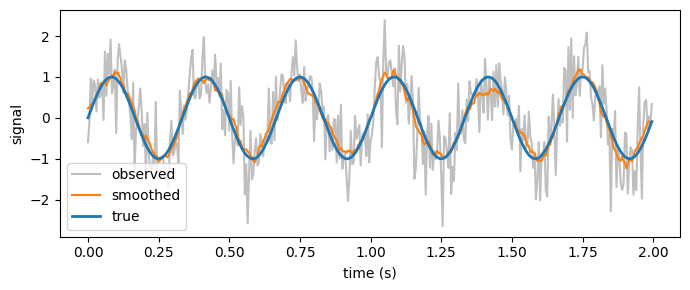

In [3]:
plt.figure(figsize=(7, 3))
plt.plot(t, obs, color="gray", alpha=0.5, label="observed")
plt.plot(t, smoothed, color="C1", label="smoothed")
plt.plot(t, true_signal, color="C0", lw=2, label="true")
plt.xlabel("time (s)")
plt.ylabel("signal")
plt.legend()
plt.tight_layout()


**Sanity checks**: smoothing should reduce variance relative to the raw observations.


In [4]:
raw_var = float(np.var(obs))
smoothed_var = float(np.var(smoothed))
print("var(raw)", raw_var)
print("var(smoothed)", smoothed_var)
print("reduction", raw_var - smoothed_var)


var(raw) 0.9029332305415513
var(smoothed) 0.47719289818572536
reduction 0.4257403323558259
